In [1]:
# وارد کردن کتابخانه‌ها
import pandas as pd
import numpy as np
import matplotlib.pyplot as pt
from sklearn.compose import ColumnTransformer as ct
from sklearn.pipeline import Pipeline as pl
from sklearn.impute import SimpleImputer as si
from sklearn.preprocessing import OneHotEncoder as ohe, StandardScaler as std
from sklearn.dummy import DummyClassifier as dc
from sklearn.linear_model import LogisticRegression as lr
from sklearn.tree import DecisionTreeClassifier as dtc
from sklearn.ensemble import RandomForestClassifier as rfc
from sklearn.model_selection import GridSearchCV as cv
from sklearn.metrics import ConfusionMatrixDisplay as cmd
from sklearn.metrics import classification_report as cr
from sklearn.model_selection import train_test_split as test
from sklearn.metrics import (
    accuracy_score as AS,
    precision_score as PS,
    recall_score as RS,
    f1_score as FS,
    roc_auc_score as RAS)

# Random Seed
RANDOM_STATE = 42

# خواندن داده 
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# تعداد سطر و ستون و نوع داده‌ها
print("Number of Rows and Columns:", df.shape)
print()
print(df.dtypes)
print()
# چاپ پنج سطر اول
df.head()

Number of Rows and Columns: (7043, 21)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# نوع و تعداد غیرخالی هر ستون
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
# آمار ستون‌های عددی
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# تعداد مقدار خالی هر ستون
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [5]:
# تعداد تکرار هر مقدار یک ستون
c = df["Churn"].value_counts()
print("Counts:", c)
# تعداد تکرار هر مقدار یک ستون به درصد
p = df["Churn"].value_counts(normalize=True) * 100
print("Percentage:", p)
# مقدارهای یکتا TotalCharge
df["TotalCharges"].unique()[:20]

Counts: Churn
No     5174
Yes    1869
Name: count, dtype: int64
Percentage: Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str

In [6]:
# تبدیل ستون‌ها به نوع داده مناسب
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())
print()
print(df.dtypes)

Missing TotalCharges: 11

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [7]:
# تعداد ردیف تکراری
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
# مقدارهای یکتا CustomerID
print("Unique customer IDs:", df["customerID"].nunique())
print("Total rows:", len(df))

Unique customer IDs: 7043
Total rows: 7043


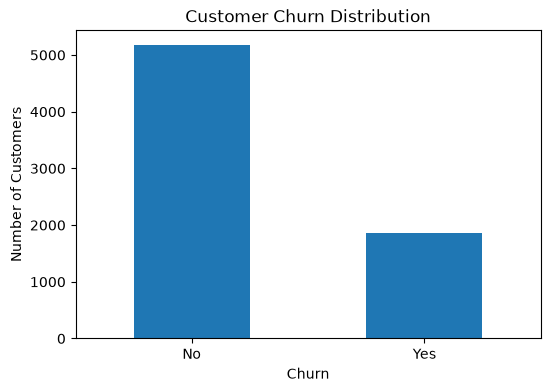

In [9]:
# نمودار
# نمودار میله‌ای تعداد مشتریان Churn=Yes و No
pt.figure(figsize=(6, 4))

df["Churn"].value_counts().plot(kind="bar")

pt.title("Customer Churn Distribution")
pt.xlabel("Churn")
pt.ylabel("Number of Customers")
pt.xticks(rotation=0)
pt.show()

In [10]:
# درصد Churn
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [11]:
# Churn بر اساس نوع قرارداد
churn_by_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


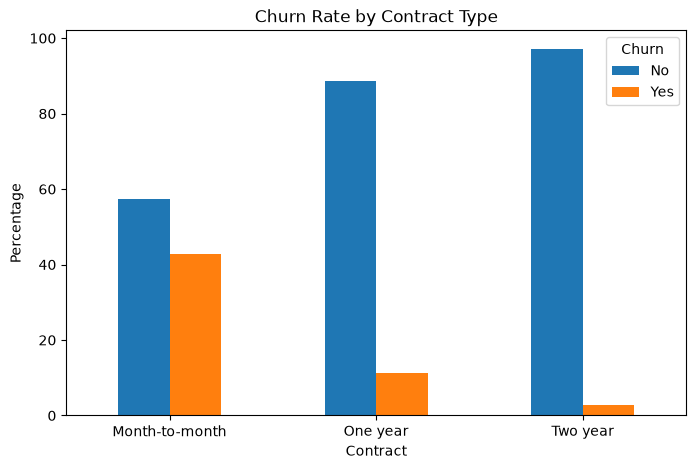

In [12]:
# نمودار
# Churn بر اساس نوع قرارداد
churn_by_contract.plot(
    kind="bar",
    figsize=(8, 5)
)

pt.title("Churn Rate by Contract Type")
pt.xlabel("Contract")
pt.ylabel("Percentage")
pt.xticks(rotation=0)
pt.legend(title="Churn")
pt.show()

In [13]:
# Churn بر اساس نوع اینترنت
churn_by_internet = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

churn_by_internet

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


<Figure size 800x500 with 0 Axes>

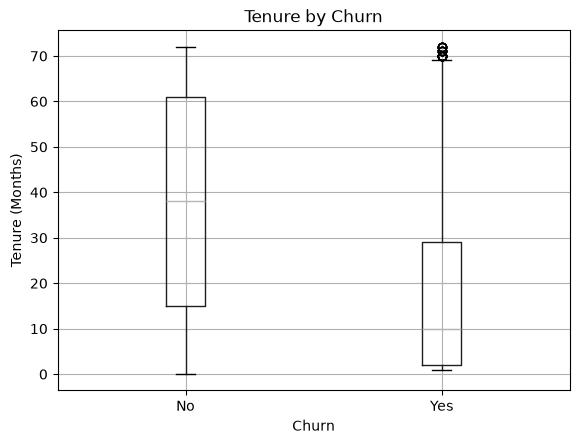

In [14]:
# نمودار
# Churn بر اساس عضویت
pt.figure(figsize=(8, 5))

df.boxplot(
    column="tenure",
    by="Churn"
)

pt.title("Tenure by Churn")
pt.suptitle("")
pt.xlabel("Churn")
pt.ylabel("Tenure (Months)")
pt.show()

<Figure size 800x500 with 0 Axes>

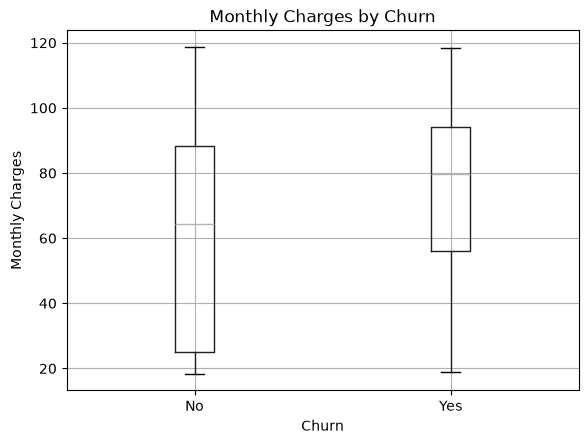

In [15]:
# نمودار
# شارژ ماهانه
pt.figure(figsize=(8, 5))

df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

pt.title("Monthly Charges by Churn")
pt.suptitle("")
pt.xlabel("Churn")
pt.ylabel("Monthly Charges")
pt.show()

In [16]:
# حذف ستون مدل
# customerID فقط شناسه است و ویژگی پیش‌بینی‌کننده نیست، پس حذف می‌شود
df_model = df.drop(columns=["customerID"]).copy()

df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
# تبدیل به عدد
df_model["Churn"] = df_model["Churn"].map({"No": 0, "Yes": 1})

df_model["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [18]:
# تعداد مقدار خالی هر ستون
missing_values = df_model.isnull().sum()

missing_values[missing_values > 0]

TotalCharges    11
dtype: int64

In [19]:
# جدا کردن ویژگی‌ها از متغیر هدف
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [20]:
# جداسازی Test قبل از هرگونه انتخاب یا تنظیم مدل
# ابتدا Test را کاملاً جدا می‌کنیم
X_train_val, X_test, y_train_val, y_test = test(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Train و Validation را جدا می‌کنیم
X_train, X_val, y_train, y_val = test(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4225, 19)
Validation: (1409, 19)
Test: (1409, 19)


In [21]:
# بررسی حفظ نسبت کلاس‌ها در مجموعه‌های Train و Validation و Test
print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train target distribution:
Churn
0    0.734675
1    0.265325
Name: proportion, dtype: float64

Validation target distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

Test target distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [22]:
# تشخیص ویژگی‌های عددی و دسته‌ای برای ساخت Pipeline
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\hp\AppData\Local\Temp\ipykernel_16340\3678061416.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [23]:
# ساخت Pipeline جداگانه برای ویژگی‌های عددی و دسته‌ای
numeric_pipeline = pl([
    ("imputer", si(strategy="median")),
    ("scaler", std())
])

categorical_pipeline = pl([
    ("imputer", si(strategy="most_frequent")),
    ("encoder", ohe(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ct([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [24]:
# ساخت مدل پایه برای داشتن معیار مقایسه
dummy_model = pl([
    ("preprocessor", preprocessor),
    ("model", dc(strategy="most_frequent"))
])

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_val)

print("Dummy Classifier")
print("Accuracy:", AS(y_val, dummy_pred))
print("Precision:", PS(y_val, dummy_pred, zero_division=0))
print("Recall:", RS(y_val, dummy_pred, zero_division=0))
print("F1:", FS(y_val, dummy_pred, zero_division=0))

Dummy Classifier
Accuracy: 0.7345635202271115
Precision: 0.0
Recall: 0.0
F1: 0.0


In [25]:
# آموزش Logistic Regression به عنوان مدل خطی پایه
logistic_model = pl([
    ("preprocessor", preprocessor),
    ("model", lr(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_val)
logistic_prob = logistic_model.predict_proba(X_val)[:, 1]

In [26]:
# آموزش Decision Tree برای مقایسه با مدل خطی
tree_model = pl([
    ("preprocessor", preprocessor),
    ("model", dtc(
        max_depth=5,
        random_state=RANDOM_STATE
    ))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_val)
tree_prob = tree_model.predict_proba(X_val)[:, 1]

In [27]:
# آموزش Random Forest برای بررسی یک مدل Ensemble
forest_model = pl([
    ("preprocessor", preprocessor),
    ("model", rfc(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_val)
forest_prob = forest_model.predict_proba(X_val)[:, 1]

In [28]:
# تابع مشترک برای محاسبه معیارهای ارزیابی مدل
def evaluate_model(model, X_data, y_data):
    predictions = model.predict(X_data)
    probabilities = model.predict_proba(X_data)[:, 1]

    return {
        "Accuracy": AS(y_data, predictions),
        "Precision": PS(y_data, predictions),
        "Recall": RS(y_data, predictions),
        "F1": FS(y_data, predictions),
        "ROC-AUC": RAS(y_data, probabilities)
    }

In [29]:
# مقایسه مدل‌های اولیه روی Validation Set
validation_results = pd.DataFrame({
    "Dummy": evaluate_model(dummy_model, X_val, y_val),
    "Logistic Regression": evaluate_model(logistic_model, X_val, y_val),
    "Decision Tree": evaluate_model(tree_model, X_val, y_val),
    "Random Forest": evaluate_model(forest_model, X_val, y_val)
}).T

validation_results

c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Accuracy,Precision,Recall,F1,ROC-AUC
Dummy,0.734564,0.000000,0.000000,0.000000,0.500000
Logistic Regression,0.803407,0.660066,0.534759,0.590842,0.835988
Decision Tree,0.787083,0.635036,0.465241,0.537037,0.814413
Random Forest,0.780696,0.618182,0.454545,0.523883,0.813493


In [30]:
# تعریف Pipeline مربوط به Random Forest برای Hyperparameter Tuning
rf_for_tuning = pl([
    ("preprocessor", preprocessor),
    ("model", rfc(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = cv(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV F1:
0.5906409587262028


In [31]:
# انتخاب بهترین تنظیمات Random Forest با Cross-Validation روی Train
tuned_model = grid_search.best_estimator_

tuned_validation_results = evaluate_model(
    tuned_model,
    X_val,
    y_val
)

tuned_validation_results

{'Accuracy': 0.7984386089425124,
 'Precision': 0.6654411764705882,
 'Recall': 0.4839572192513369,
 'F1': 0.5603715170278638,
 'ROC-AUC': 0.8308649151360149}

In [32]:
# مقایسه Random Forest قبل و بعد از Tuning
comparison = pd.DataFrame({
    "Random Forest Before Tuning": evaluate_model(
        forest_model,
        X_val,
        y_val
    ),
    "Random Forest After Tuning": tuned_validation_results
}).T

comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest Before Tuning,0.780696,0.618182,0.454545,0.523883,0.813493
Random Forest After Tuning,0.798439,0.665441,0.483957,0.560372,0.830865


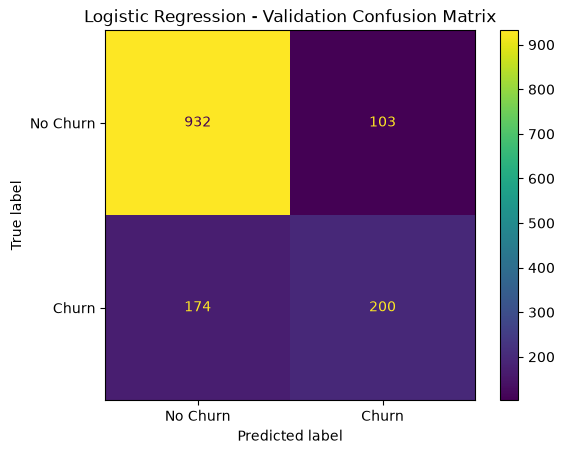

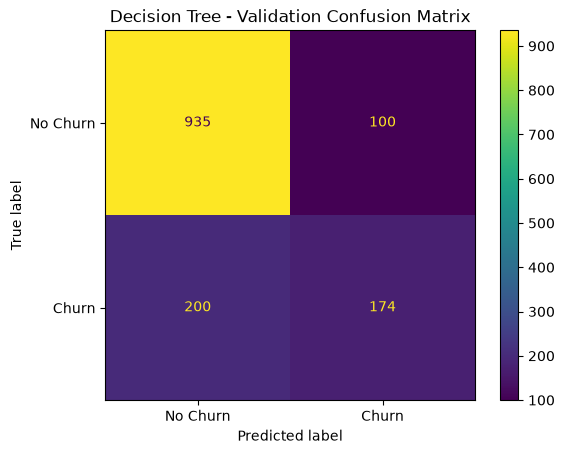

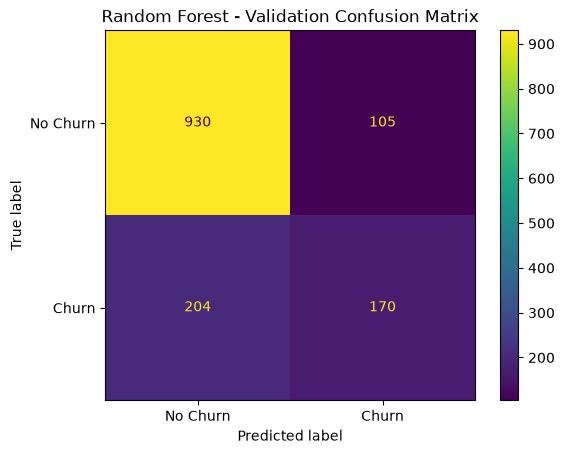

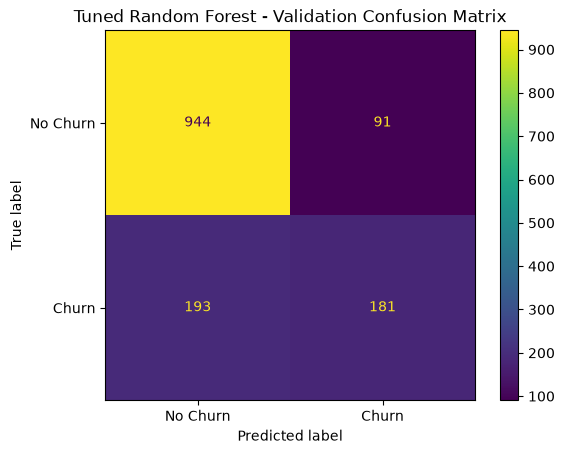

In [33]:
# آماده‌سازی مدل‌ها برای تحلیل خطا
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model,
    "Tuned Random Forest": tuned_model
}

for name, model in models.items():
    y_pred = model.predict(X_val)

    cmd.from_predictions(
        y_val,
        y_pred,
        display_labels=["No Churn", "Churn"]
    )

    pt.title(f"{name} - Validation Confusion Matrix")
    pt.show()

In [34]:
# ساخت جدول نمونه‌های اشتباه پیش‌بینی‌شده توسط مدل
y_val_pred = forest_model.predict(X_val)

error_df = X_val.copy()

error_df["actual"] = y_val.values
error_df["predicted"] = y_val_pred

error_df["error"] = (
    error_df["actual"] != error_df["predicted"]
)

print("Total validation samples:", len(error_df))
print("Total errors:", error_df["error"].sum())

Total validation samples: 1409
Total errors: 309


In [35]:
# تفکیک False Positive و False Negative
false_positive = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted"] == 1)
]

false_negative = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
]

print("False Positives:", len(false_positive))
print("False Negatives:", len(false_negative))

False Positives: 105
False Negatives: 204


In [36]:
# نمایش چند نمونه از خطاهای مدل
error_df[error_df["error"]].head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,actual,predicted,error
2103,Male,1,Yes,No,11,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.20,834.7,0,1,True
6096,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.20,70.2,0,1,True
4286,Male,0,Yes,No,9,Yes,Yes,Fiber optic,Yes,No,...,No,Yes,Month-to-month,Yes,Electronic check,88.05,801.3,0,1,True


In [37]:
# بررسی نرخ خطا بر اساس نوع قرارداد
contract_error = pd.crosstab(
    X_val["Contract"],
    error_df["error"],
    normalize="index") * 100

contract_error

error,False,True
Contract,,
Month-to-month,67.010309,32.989691
One year,87.012987,12.987013
Two year,96.000000,4.000000


In [38]:
# بررسی نرخ خطا بر اساس نوع سرویس اینترنت
internet_error = pd.crosstab(
    X_val["InternetService"],
    error_df["error"],
    normalize="index"
) * 100

internet_error

error,False,True
InternetService,,
DSL,80.993521,19.006479
Fiber optic,69.375000,30.625000
No,91.830065,8.169935


In [39]:
# استخراج اهمیت ویژگی‌ها از Random Forest
feature_names = (
    forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    forest_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,num__TotalCharges,0.154513
1,num__tenure,0.137719
2,num__MonthlyCharges,0.133317
36,cat__Contract_Month-to-month,0.055480
18,cat__OnlineSecurity_No,0.033482
27,cat__TechSupport_No,0.028237
43,cat__PaymentMethod_Electronic check,0.028218
16,cat__InternetService_Fiber optic,0.026082
38,cat__Contract_Two year,0.019453
0,num__SeniorCitizen,0.019327


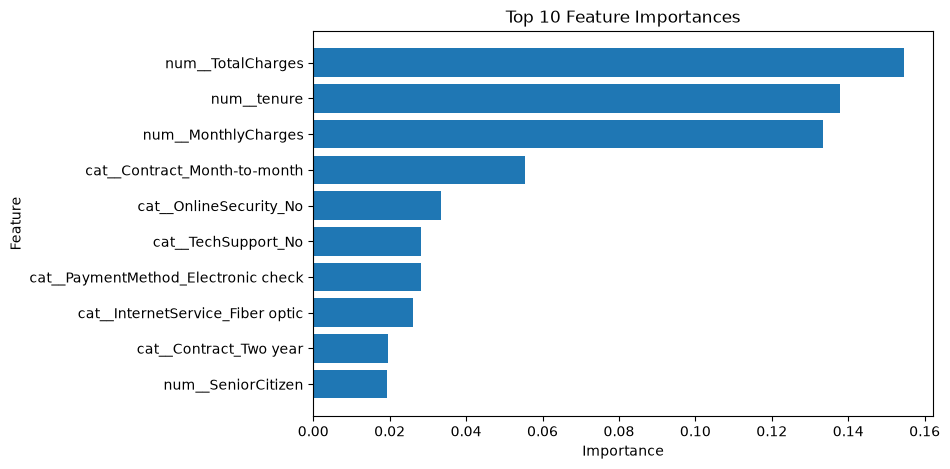

In [40]:
# نمایش مهم‌ترین ویژگی‌ها به صورت نمودار
top_features = feature_importance.head(10).sort_values(
    "Importance"
)

pt.figure(figsize=(8, 5))

pt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

pt.title("Top 10 Feature Importances")
pt.xlabel("Importance")
pt.ylabel("Feature")
pt.show()

In [41]:
validation_results.sort_values(
    "F1",
    ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.803407,0.660066,0.534759,0.590842,0.835988
Decision Tree,0.787083,0.635036,0.465241,0.537037,0.814413
Random Forest,0.780696,0.618182,0.454545,0.523883,0.813493
Dummy,0.734564,0.000000,0.000000,0.000000,0.500000


In [42]:
# انتخاب مدل نهایی فقط بر اساس Validation و بدون استفاده از Test

# نتیجه مدل‌های پایه را با نتیجه Random Forest تنظیم‌شده ترکیب می‌کنیم.
model_selection_results = validation_results.copy()
model_selection_results.loc["Tuned Random Forest"] = tuned_validation_results

# مرتب‌سازی بر اساس F1 چون در این پروژه تمرکز اصلی روی تشخیص Churn است.
model_selection_results = model_selection_results.sort_values(
    "F1",
    ascending=False
)

model_selection_results

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.803407,0.660066,0.534759,0.590842,0.835988
Tuned Random Forest,0.798439,0.665441,0.483957,0.560372,0.830865
Decision Tree,0.787083,0.635036,0.465241,0.537037,0.814413
Random Forest,0.780696,0.618182,0.454545,0.523883,0.813493
Dummy,0.734564,0.000000,0.000000,0.000000,0.500000


In [43]:
# ارزیابی مدل نهایی روی Test Set که تا این مرحله در انتخاب مدل استفاده نشده است

# بالاترین F1 روی Validation به عنوان معیار انتخاب مدل نهایی استفاده می‌شود.
final_model_name = model_selection_results["F1"].idxmax()

# مدل متناظر با نام انتخاب‌شده را مشخص می‌کنیم.
if final_model_name == "Tuned Random Forest":
    final_model = tuned_model
else:
    final_model = models[final_model_name]

print("Final model:", final_model_name)

# فقط در این مرحله Test Set برای ارزیابی نهایی استفاده می‌شود.
final_test_results = evaluate_model(
    final_model,
    X_test,
    y_test
)

final_test_results

Final model: Logistic Regression


{'Accuracy': 0.8026969481902059,
 'Precision': 0.6509433962264151,
 'Recall': 0.553475935828877,
 'F1': 0.5982658959537572,
 'ROC-AUC': 0.8427652483918469}

In [44]:
# نمایش معیارهای نهایی مدل روی Test Set
final_results = pd.DataFrame(
    [final_test_results],
    index=["Final Model"]
)

final_results

,Accuracy,Precision,Recall,F1,ROC-AUC
Final Model,0.802697,0.650943,0.553476,0.598266,0.842765


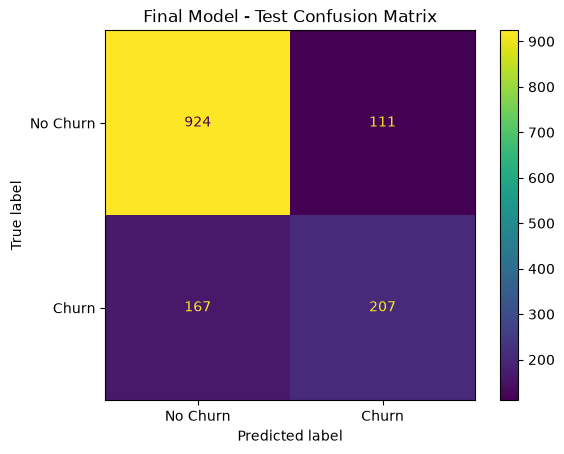

In [45]:
# نمایش Confusion Matrix برای مدل نهایی روی Test Set
final_test_pred = final_model.predict(X_test)

cmd.from_predictions(
    y_test,
    final_test_pred,
    display_labels=["No Churn", "Churn"]
)

pt.title("Final Model - Test Confusion Matrix")
pt.show()

In [46]:
# نمایش جزئیات Precision، Recall و F1 برای هر کلاس
print(
    cr(
        y_test,
        final_test_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

